In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
import matplotlib.pyplot as plt

In [2]:
qc = QuantumCircuit(13, 5)

qc.x(0)
qc.x(1)
qc.x(5)

qc.ccx(0,4,9)
qc.cx(0,4)
qc.ccx(8,4,9)
qc.cx(8,4)

qc.ccx(1,5,10)
qc.cx(1,5)
qc.ccx(9,5,10)
qc.cx(9,5)

qc.ccx(2,6,11)
qc.cx(2,6)
qc.ccx(10,6,11)
qc.cx(10,6)

qc.ccx(3,7,12)
qc.cx(3,7)
qc.ccx(11,7,12)
qc.cx(11,7)

qc.measure(4,0)
qc.measure(5,1)
qc.measure(6,2)
qc.measure(7,3)
qc.measure(12,4)

In [3]:
sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1).result()

counts = result.get_counts()
print("Output:", counts)

Output: {'00101': 1}


In [4]:
for k in counts:
    carry = k[0]
    summation = k[1:]

    print("Sum (binary):", summation)
    print("Carry:", carry)
    print("Decimal Result:", int(summation, 2))

Sum (binary): 0101
Carry: 0
Decimal Result: 5


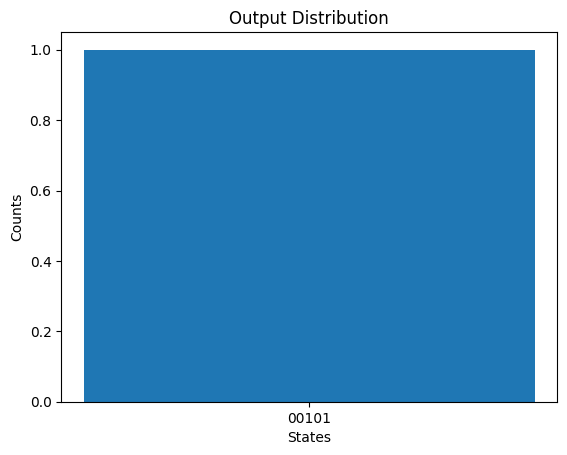

In [5]:
plt.bar(list(counts.keys()), list(counts.values()))
plt.title("Output Distribution")
plt.xlabel("States")
plt.ylabel("Counts")
plt.show()

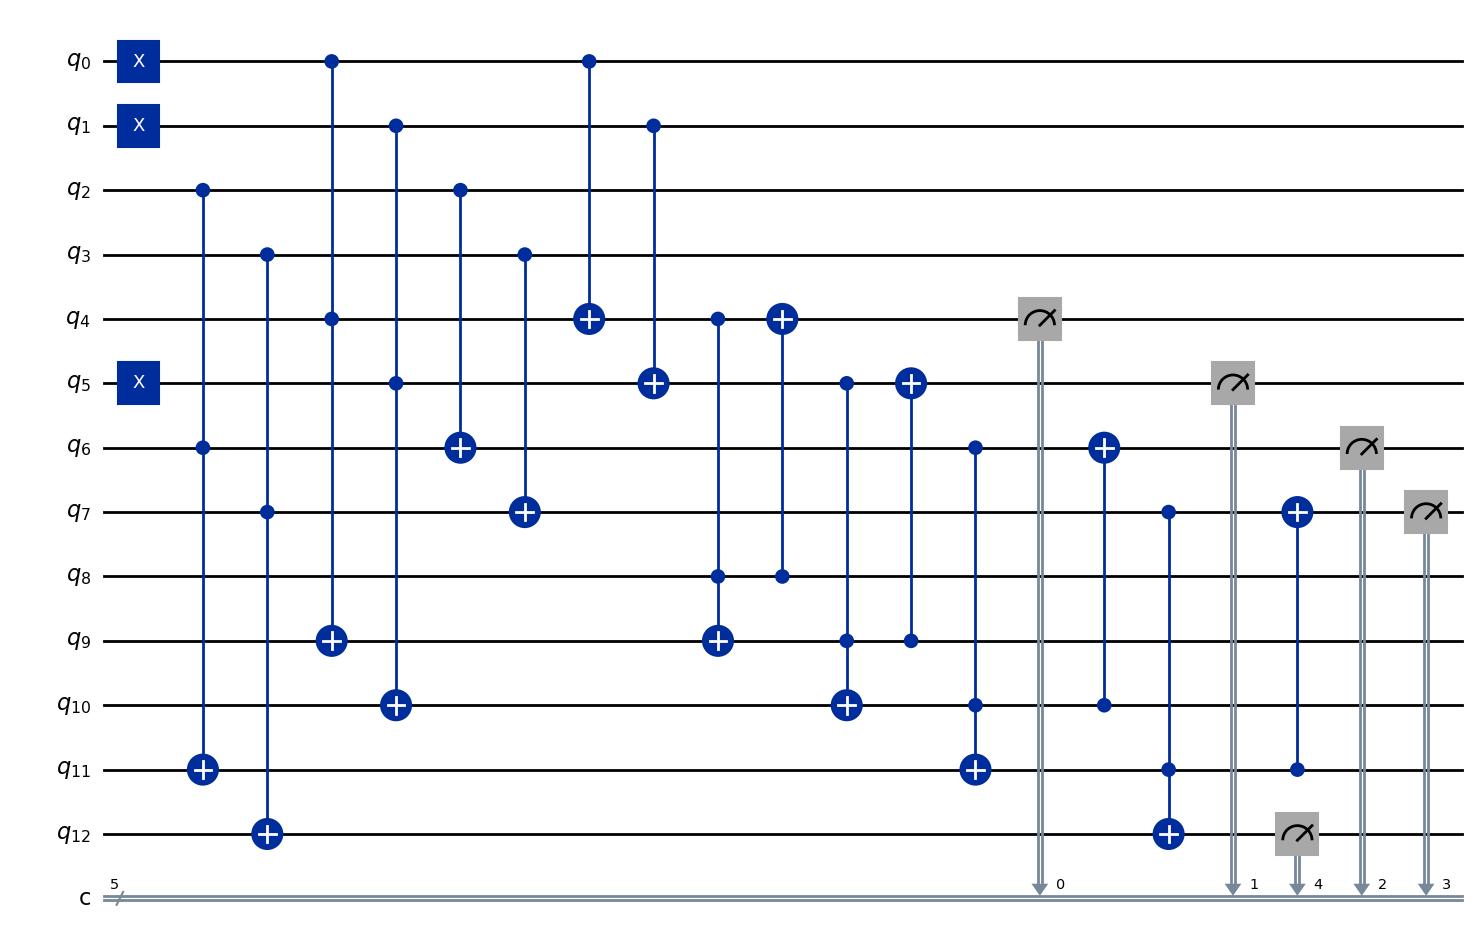

In [6]:
qc.draw('mpl', fold=-1)